<a href="https://colab.research.google.com/github/spidersweep/f1-pyspark-analysis/blob/main/partie2_analyse_exploratoire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏎️ Partie 2 — Analyse Exploratoire & Visualisations F1
**Responsable : Karissy CISSE**

Objectif : Explorer les données F1 nettoyées par Lara et répondre à des questions clés sur les pilotes, les saisons et les performances, en vue de construire un **score composite « Meilleur Pilote de l'Histoire »**.

---

In [1]:
# --- PROJET PYSPARK — F1 : Qui est le Meilleur Pilote de l'Histoire ? -------------
# --- Partie 2 : Analyse Exploratoire & Visualisations -----------------------------
# --- Responsable : Karissy Cisse --------------------------------------------------

!pip install pyspark

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# je vais Cloner le repo GitHub directement dans Colab pour pouvoir travailler facilement
!git clone https://github.com/spidersweep/f1-pyspark-analysis.git

fatal: destination path 'f1-pyspark-analysis' already exists and is not an empty directory.


In [3]:
import os
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\f1-pyspark-analysis\data\output\stats_pilotes_partie2\part-00000-b272fcfa-b5f8-4712-a2b6-4661e7ef209f-c000.csv
.\f1-pyspark-analysis\data\processed\constructors_clean.csv
.\f1-pyspark-analysis\data\processed\constructor_standings_clean.csv
.\f1-pyspark-analysis\data\processed\drivers_clean.csv
.\f1-pyspark-analysis\data\processed\driver_standings_clean.csv
.\f1-pyspark-analysis\data\processed\races_clean.csv
.\f1-pyspark-analysis\data\processed\results_clean.csv
.\f1-pyspark-analysis\data\raw\circuits.csv
.\f1-pyspark-analysis\data\raw\constructors.csv
.\f1-pyspark-analysis\data\raw\constructor_results.csv
.\f1-pyspark-analysis\data\raw\constructor_standings.csv
.\f1-pyspark-analysis\data\raw\drivers.csv
.\f1-pyspark-analysis\data\raw\driver_standings.csv
.\f1-pyspark-analysis\data\raw\lap_times.csv
.\f1-pyspark-analysis\data\raw\pit_stops.csv
.\f1-pyspark-analysis\data\raw\qualifying.csv
.\f1-pyspark-analysis\data\raw\races.csv
.\f1-pyspark-analysis\data\raw\results.csv
.\f1-pyspark

In [4]:
os.makedirs("f1-pyspark-analysis/visualisations", exist_ok=True)
print("✅ Dossier visualisations créé !")

✅ Dossier visualisations créé !


In [5]:
DATA_PATH = "f1-pyspark-analysis/data/processed/"

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import *

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Style global matplotlib/seaborn
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#16213e',
    'axes.edgecolor':   '#e94560',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#0f3460',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
})
F1_RED   = '#e94560'
F1_GOLD  = '#f5a623'
F1_BLUE  = '#0f3460'

spark = SparkSession.builder \
    .appName("F1_Analyse_Exploratoire") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"✅ Spark version : {spark.version}")

ModuleNotFoundError: No module named 'matplotlib'

## 1. Chargement des données nettoyées (output Lara)

In [12]:
DATA_PATH = "f1-pyspark-analysis/data/processed/" # chemin

results      = spark.read.csv(DATA_PATH + "results_clean.csv",          header=True, inferSchema=True)
races        = spark.read.csv(DATA_PATH + "races_clean.csv",            header=True, inferSchema=True)
drivers      = spark.read.csv(DATA_PATH + "drivers_clean.csv",          header=True, inferSchema=True)
constructors = spark.read.csv(DATA_PATH + "constructors_clean.csv",     header=True, inferSchema=True)
drv_stand    = spark.read.csv(DATA_PATH + "driver_standings_clean.csv",        header=True, inferSchema=True)
cst_stand    = spark.read.csv(DATA_PATH + "constructor_standings_clean.csv", header=True, inferSchema=True)

print("📦 Lignes chargées :")
for name, df in [("results", results), ("races", races), ("drivers", drivers),
                 ("constructors", constructors), ("driver_standing", drv_stand),
                 ("constructor_standing", cst_stand)]:
    print(f"  {name:<25} → {df.count():>6} lignes | {len(df.columns)} colonnes")

NameError: name 'spark' is not defined

In [ ]:
# Aperçu rapide des schémas
print("=== RESULTS ===")
results.printSchema()
print("\n=== RACES ===")
races.printSchema()
print("\n=== DRIVERS ===")
drivers.printSchema()

=== RESULTS ===
root
 |-- resultId: integer (nullable = true)
 |-- raceId: integer (nullable = true)
 |-- driverId: integer (nullable = true)
 |-- constructorId: integer (nullable = true)
 |-- number: integer (nullable = true)
 |-- grid: integer (nullable = true)
 |-- position: integer (nullable = true)
 |-- positionText: string (nullable = true)
 |-- positionOrder: integer (nullable = true)
 |-- points: double (nullable = true)
 |-- laps: integer (nullable = true)
 |-- time: string (nullable = true)
 |-- milliseconds: double (nullable = true)
 |-- fastestLap: integer (nullable = true)
 |-- rank: integer (nullable = true)
 |-- fastestLapTime: string (nullable = true)
 |-- fastestLapSpeed: double (nullable = true)
 |-- statusId: integer (nullable = true)
 |-- position_int: double (nullable = true)
 |-- finished: boolean (nullable = true)


=== RACES ===
root
 |-- raceId: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- round: integer (nullable = true)
 |-- circuitId: 

In [ ]:
# Cache des tables fréquemment utilisées
results.cache()
races.cache()
drivers.cache()
print("✅ Tables mises en cache")

✅ Tables mises en cache


## 2. Vue d'ensemble — statistiques générales

In [ ]:
nb_saisons  = races.select("year").distinct().count()
nb_courses  = races.count()
nb_pilotes  = drivers.count()
nb_ecueries = constructors.count()

annee_min = races.agg(F.min("year")).collect()[0][0]
annee_max = races.agg(F.max("year")).collect()[0][0]

print("🏁 OVERVIEW DU DATASET F1")
print(f"  Période couverte : {annee_min} → {annee_max} ({nb_saisons} saisons)")
print(f"  Nombre de Grands Prix : {nb_courses}")
print(f"  Pilotes uniques       : {nb_pilotes}")
print(f"  Écuries uniques       : {nb_ecueries}")

🏁 OVERVIEW DU DATASET F1
  Période couverte : 1950 → 2024 (75 saisons)
  Nombre de Grands Prix : 1125
  Pilotes uniques       : 861
  Écuries uniques       : 212


## 3. Analyse exploratoire — Questions clés F1

### Q1 — Quels pilotes ont le plus de victoires ?

In [ ]:
# Jointure results + drivers, filtre position = 1
victories = (
    results
    .filter(F.col("positionOrder") == 1)
    .join(drivers, "driverId")
    .groupBy("driverId", "forename", "surname")
    .agg(F.count("*").alias("nb_victoires"))
    .withColumn("pilote", F.concat(F.col("forename"), F.lit(" "), F.col("surname")))
    .orderBy(F.desc("nb_victoires"))
)

top10_victoires = victories.limit(10).toPandas()
print("🏆 Top 10 pilotes — Victoires en carrière :")
display(top10_victoires[["pilote", "nb_victoires"]])

🏆 Top 10 pilotes — Victoires en carrière :


,pilote,nb_victoires
0,Lewis Hamilton,105
1,Michael Schumacher,91
2,Max Verstappen,63
3,Sebastian Vettel,53
4,Alain Prost,51
5,Ayrton Senna,41
6,Fernando Alonso,32
7,Nigel Mansell,31
8,Jackie Stewart,27
9,Niki Lauda,25


### Q2 — Quels pilotes ont le plus de podiums ?

In [ ]:
podiums = (
    results
    .filter(F.col("positionOrder") <= 3)
    .join(drivers, "driverId")
    .groupBy("driverId", "forename", "surname")
    .agg(
        F.count("*").alias("nb_podiums"),
        F.sum(F.when(F.col("positionOrder") == 1, 1).otherwise(0)).alias("victoires"),
        F.sum(F.when(F.col("positionOrder") == 2, 1).otherwise(0)).alias("2e_place"),
        F.sum(F.when(F.col("positionOrder") == 3, 1).otherwise(0)).alias("3e_place"),
    )
    .withColumn("pilote", F.concat(F.col("forename"), F.lit(" "), F.col("surname")))
    .orderBy(F.desc("nb_podiums"))
)

top10_podiums = podiums.limit(10).toPandas()
print("🥇🥈🥉 Top 10 pilotes — Podiums en carrière :")
display(top10_podiums[["pilote", "victoires", "2e_place", "3e_place", "nb_podiums"]])

🥇🥈🥉 Top 10 pilotes — Podiums en carrière :


,pilote,victoires,2e_place,3e_place,nb_podiums
0,Lewis Hamilton,105,57,40,202
1,Michael Schumacher,91,43,21,155
2,Sebastian Vettel,53,36,33,122
3,Max Verstappen,63,32,17,112
4,Alain Prost,51,35,20,106
5,Fernando Alonso,32,40,34,106
6,Kimi Räikkönen,21,37,45,103
7,Ayrton Senna,41,23,16,80
8,Rubens Barrichello,11,29,28,68
9,Valtteri Bottas,10,29,28,67


### Q3 — Taux de victoire (victoires / courses disputées)

In [ ]:
courses_par_pilote = (
    results
    .join(drivers, "driverId")
    .groupBy("driverId", "forename", "surname")
    .agg(
        F.count("*").alias("courses_disputees"),
        F.sum(F.when(F.col("positionOrder") == 1, 1).otherwise(0)).alias("victoires"),
        F.sum(F.when(F.col("positionOrder") <= 3, 1).otherwise(0)).alias("podiums"),
        F.avg("points").alias("points_moy_par_course"),
        F.sum("points").alias("points_total"),
    )
    .withColumn("pilote", F.concat(F.col("forename"), F.lit(" "), F.col("surname")))
    .withColumn("taux_victoire", F.round(F.col("victoires") / F.col("courses_disputees") * 100, 2))
    .withColumn("taux_podium", F.round(F.col("podiums") / F.col("courses_disputees") * 100, 2))
    .filter(F.col("courses_disputees") >= 50)   # Seuil : au moins 50 courses
    .orderBy(F.desc("taux_victoire"))
)

top_taux = courses_par_pilote.limit(15).toPandas()
print("📊 Top 15 taux de victoire (min. 50 courses) :")
display(top_taux[["pilote", "courses_disputees", "victoires", "taux_victoire", "taux_podium", "points_moy_par_course"]])

📊 Top 15 taux de victoire (min. 50 courses) :


,pilote,courses_disputees,victoires,taux_victoire,taux_podium,points_moy_par_course
0,Juan Fangio,58,24,41.38,60.34,4.812759
1,Jim Clark,73,25,34.25,43.84,3.753425
2,Max Verstappen,209,63,30.14,53.59,13.935407
3,Michael Schumacher,308,91,29.55,50.32,5.084416
4,Lewis Hamilton,356,105,29.49,56.74,13.540730
5,Jackie Stewart,100,27,27.00,43.00,3.600000
6,Ayrton Senna,162,41,25.31,49.38,3.790123
7,Alain Prost,202,51,25.25,52.48,3.952970
8,Stirling Moss,73,16,21.92,32.88,2.554795
9,Damon Hill,122,22,18.03,34.43,2.950820


### Q4 — Évolution du nombre de victoires par saison (top pilotes)

In [ ]:
# Top 5 pilotes par victoires
top5_ids = victories.limit(5).select("driverId", "pilote").toPandas()
top5_list = top5_ids["driverId"].tolist()

evol_victoires = (
    results
    .filter((F.col("positionOrder") == 1) & (F.col("driverId").isin(top5_list)))
    .join(races.select("raceId", "year"), "raceId")
    .join(drivers.select("driverId", "forename", "surname"), "driverId")
    .withColumn("pilote", F.concat(F.col("forename"), F.lit(" "), F.col("surname")))
    .groupBy("year", "pilote")
    .agg(F.count("*").alias("victoires_saison"))
    .orderBy("year")
).toPandas()

print(f"Données évolution prêtes : {evol_victoires.shape}")

Données évolution prêtes : (61, 3)


### Q5 — Victoires cumulées dans le temps (window function)

In [ ]:
# Window function : cumul des victoires race par race pour chaque pilote
w_cumul = Window.partitionBy("driverId").orderBy("raceId")

cumul_victoires = (
    results
    .filter(F.col("driverId").isin(top5_list))
    .join(races.select("raceId", "year", "round"), "raceId")
    .join(drivers.select("driverId", "forename", "surname"), "driverId")
    .withColumn("pilote", F.concat(F.col("forename"), F.lit(" "), F.col("surname")))
    .withColumn("est_victoire", F.when(F.col("positionOrder") == 1, 1).otherwise(0))
    .withColumn("victoires_cumulees", F.sum("est_victoire").over(w_cumul))
    .select("pilote", "year", "round", "raceId", "victoires_cumulees")
    .orderBy("pilote", "raceId")
).toPandas()

print(f"✅ Victoires cumulées calculées : {cumul_victoires.shape}")
cumul_victoires.head(10)

✅ Victoires cumulées calculées : (1375, 5)


,pilote,year,round,raceId,victoires_cumulees
0,Alain Prost,1993,1,273,1
1,Alain Prost,1993,2,274,1
2,Alain Prost,1993,3,275,1
3,Alain Prost,1993,4,276,2
4,Alain Prost,1993,5,277,3
5,Alain Prost,1993,6,278,3
6,Alain Prost,1993,7,279,4
7,Alain Prost,1993,8,280,5
8,Alain Prost,1993,9,281,6
9,Alain Prost,1993,10,282,7


### Q6 — Titres de champion du monde par pilote

In [ ]:
# Le champion est le pilote avec position = 1 dans les standings en fin de saison
# On prend le round max par année
last_round = drv_stand.join(races.select("raceId", "year", "round"), "raceId")

w_saison = Window.partitionBy("year")
champions = (
    last_round
    .withColumn("max_round", F.max("round").over(w_saison))
    .filter(F.col("round") == F.col("max_round"))
    .filter(F.col("position") == 1)
    .join(drivers.select("driverId", "forename", "surname"), "driverId")
    .withColumn("pilote", F.concat(F.col("forename"), F.lit(" "), F.col("surname")))
    .groupBy("pilote", "driverId")
    .agg(F.count("*").alias("titres_wdc"))
    .orderBy(F.desc("titres_wdc"))
)

top_champions = champions.limit(15).toPandas()
print("🏆 Champions du Monde F1 (par nombre de titres) :")
display(top_champions[["pilote", "titres_wdc"]])

🏆 Champions du Monde F1 (par nombre de titres) :


,pilote,titres_wdc
0,Michael Schumacher,7
1,Lewis Hamilton,7
2,Juan Fangio,5
3,Sebastian Vettel,4
4,Alain Prost,4
5,Max Verstappen,4
6,Jackie Stewart,3
7,Nelson Piquet,3
8,Ayrton Senna,3
9,Jack Brabham,3


### Q7 — Points moyens par course (performance relative / époque)

In [ ]:
# Note : le barème de points a changé en F1 (ex: 10 pts max avant 2010, 25 pts après)
# On normalise par le max de points disponibles cette saison-là

max_pts_saison = (
    results
    .join(races.select("raceId", "year"), "raceId")
    .groupBy("year", "raceId")
    .agg(F.max("points").alias("max_pts_course"))
    .groupBy("year")
    .agg(F.avg("max_pts_course").alias("pts_max_moy_saison"))
)

perf_normalisee = (
    results
    .join(races.select("raceId", "year"), "raceId")
    .join(drivers.select("driverId", "forename", "surname"), "driverId")
    .withColumn("pilote", F.concat(F.col("forename"), F.lit(" "), F.col("surname")))
    .groupBy("pilote", "driverId", "year")
    .agg(F.avg("points").alias("pts_moy"))
    .join(max_pts_saison, "year")
    .withColumn("score_norme", F.round(F.col("pts_moy") / F.col("pts_max_moy_saison") * 100, 2))
    .filter(F.col("driverId").isin(top5_list))
).toPandas()

print(f"✅ Performance normalisée calculée : {perf_normalisee.shape}")

✅ Performance normalisée calculée : (76, 6)


---
## 4. 📊 Visualisations

### Graphique 1 — Top 10 Pilotes : Victoires vs Podiums (Seaborn)

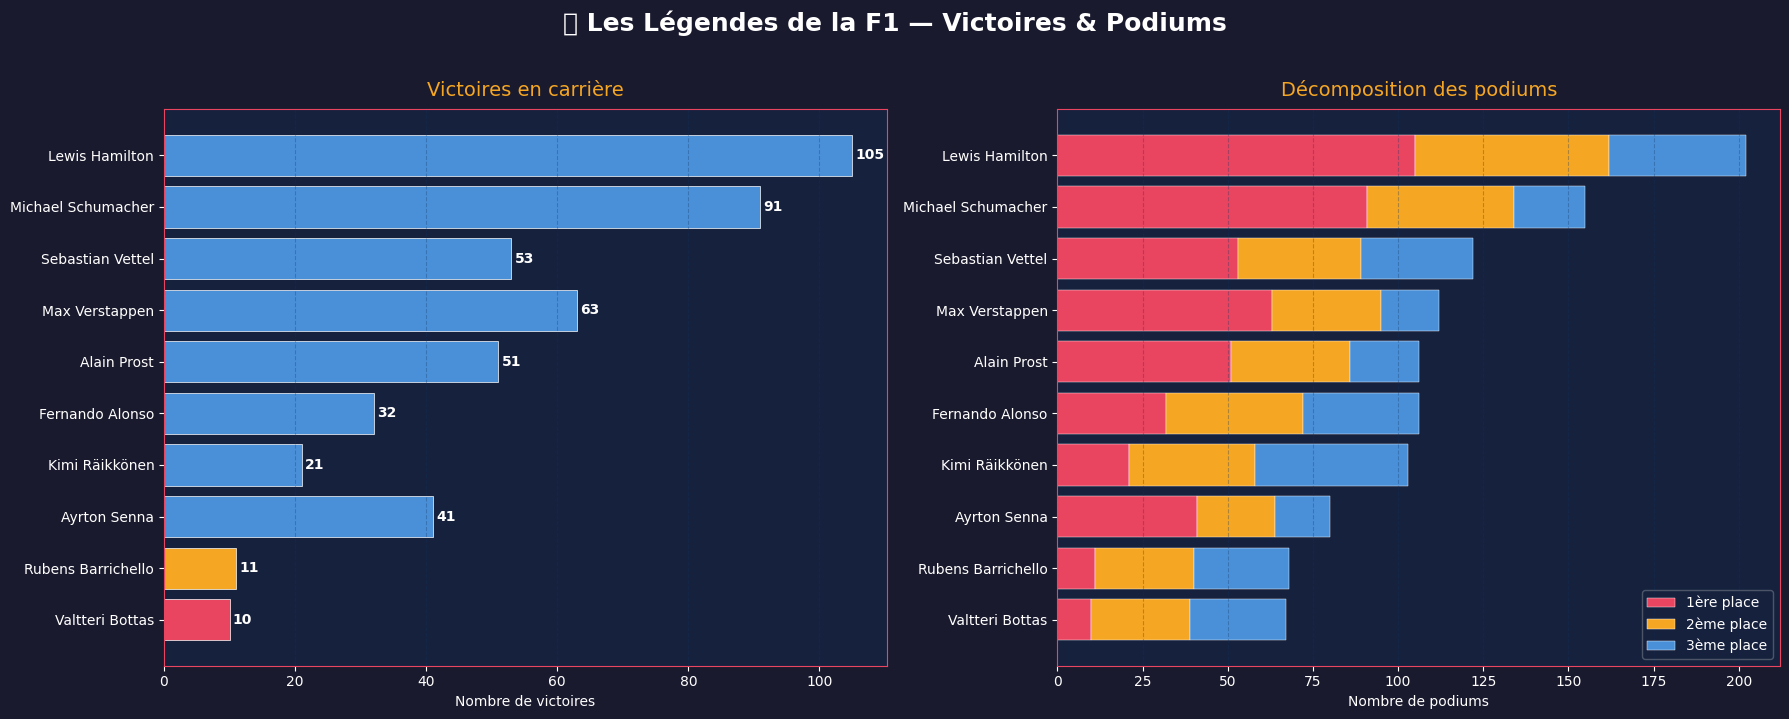

💾 Graphique 1 sauvegardé


In [ ]:
# Merge victoires + podiums pour top 10
top10_merge = top10_podiums.copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("🏎️ Les Légendes de la F1 — Victoires & Podiums", fontsize=18, fontweight='bold',
             color='white', y=1.02)

# --- Subplot 1 : Victoires ---
ax1 = axes[0]
bars1 = ax1.barh(
    top10_merge["pilote"][::-1],
    top10_merge["victoires"][::-1],
    color=[F1_RED if i == 0 else F1_GOLD if i == 1 else '#4a90d9' for i in range(10)],
    edgecolor='white', linewidth=0.5
)
ax1.set_title("Victoires en carrière", color=F1_GOLD, fontsize=14, pad=10)
ax1.set_xlabel("Nombre de victoires", color='white')
ax1.grid(axis='x', alpha=0.3)
for bar, val in zip(bars1, top10_merge["victoires"][::-1]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', color='white', fontweight='bold', fontsize=10)

# --- Subplot 2 : Décomposition podiums (stacked) ---
ax2 = axes[1]
pilots = top10_merge["pilote"][::-1].values
v1     = top10_merge["victoires"][::-1].values
v2     = top10_merge["2e_place"][::-1].values
v3     = top10_merge["3e_place"][::-1].values

ax2.barh(pilots, v1, color=F1_RED,  label="1ère place", edgecolor='white', linewidth=0.3)
ax2.barh(pilots, v2, left=v1, color=F1_GOLD, label="2ème place", edgecolor='white', linewidth=0.3)
ax2.barh(pilots, v3, left=v1+v2, color='#4a90d9', label="3ème place", edgecolor='white', linewidth=0.3)

ax2.set_title("Décomposition des podiums", color=F1_GOLD, fontsize=14, pad=10)
ax2.set_xlabel("Nombre de podiums", color='white')
ax2.grid(axis='x', alpha=0.3)
ax2.legend(loc='lower right', framealpha=0.3, labelcolor='white')

plt.tight_layout()
plt.savefig("f1-pyspark-analysis/visualisations/graph1_victoires_podiums.png", dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')

plt.show()
print("💾 Graphique 1 sauvegardé")

**📝 Interprétation :** Lewis Hamilton domine le classement absolu en victoires et podiums, suivi de Michael Schumacher. Cependant, ces chiffres ne tiennent pas compte des époques différentes ni de la qualité des voitures — d'où la nécessité du score composite (Partie 3 — Salma).

### Graphique 2 — Évolution cumulée des victoires dans le temps (Plotly)

In [ ]:
fig2 = px.line(
    cumul_victoires,
    x="raceId",
    y="victoires_cumulees",
    color="pilote",
    title="🏁 Évolution cumulée des victoires — Top 5 pilotes de l'Histoire",
    labels={"raceId": "Grand Prix (index chronologique)",
            "victoires_cumulees": "Victoires cumulées",
            "pilote": "Pilote"},
    template="plotly_dark",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig2.update_layout(
    title_font_size=16,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    plot_bgcolor='#16213e',
    paper_bgcolor='#1a1a2e',
    font_color='white',
    hovermode='x unified'
)
fig2.update_traces(line_width=2.5)
fig2.write_html("f1-pyspark-analysis/visualisations/graph2_victoires_cumulees.html")
fig2.show()
print("💾 Graphique 2 sauvegardé")

💾 Graphique 2 sauvegardé


**📝 Interprétation :** La courbe cumulée révèle la **vitesse d'accumulation** des victoires : Schumacher a eu une ascension très rapide dans les années 2000, tandis qu'Hamilton a progressé de façon régulière et sur une plus longue carrière. Ayrton Senna, décédé en 1994, avait un rythme comparable aux légendes modernes malgré une carrière plus courte.

### Graphique 3 — Taux de victoire vs Nombre de courses (Scatter + Taille = Points totaux)

In [ ]:
top_taux_etendu = courses_par_pilote.limit(30).toPandas()

fig3 = px.scatter(
    top_taux_etendu,
    x="courses_disputees",
    y="taux_victoire",
    size="points_total",
    color="taux_podium",
    hover_name="pilote",
    hover_data={"victoires": True, "points_moy_par_course": ":.1f"},
    title="🎯 Taux de victoire vs Longévité — Top 30 pilotes (min. 50 courses)",
    labels={
        "courses_disputees": "Courses disputées",
        "taux_victoire": "Taux de victoire (%)",
        "taux_podium": "Taux de podium (%)",
        "points_total": "Points total"
    },
    template="plotly_dark",
    color_continuous_scale="RdYlGn",
    size_max=50
)

# Zone d'excellence
fig3.add_shape(type="rect",
    x0=150, x1=top_taux_etendu["courses_disputees"].max() + 10,
    y0=25,  y1=top_taux_etendu["taux_victoire"].max() + 2,
    fillcolor="rgba(249, 166, 35, 0.07)",
    line=dict(color=F1_GOLD, width=1.5, dash="dot")
)
fig3.add_annotation(x=200, y=top_taux_etendu["taux_victoire"].max() - 2,
    text="Zone d'excellence", showarrow=False,
    font=dict(color=F1_GOLD, size=11))

fig3.update_layout(
    plot_bgcolor='#16213e', paper_bgcolor='#1a1a2e',
    font_color='white', title_font_size=15
)
fig3.write_html("f1-pyspark-analysis/visualisations/graph3_taux_victoire_longevite.html")
fig3.show()
print("💾 Graphique 3 sauvegardé")

💾 Graphique 3 sauvegardé


*📝 Interprétation :** Ce scatter plot est clé pour notre problématique : un pilote dans la **zone dorée** (haut taux de victoire ET longue carrière) est un candidat sérieux au titre de GOAT. La taille des bulles (points totaux) et la couleur (taux de podium) ajoutent deux dimensions supplémentaires à l'analyse.

### Graphique 4 bonus — Titres WDC par pilote (matplotlib)

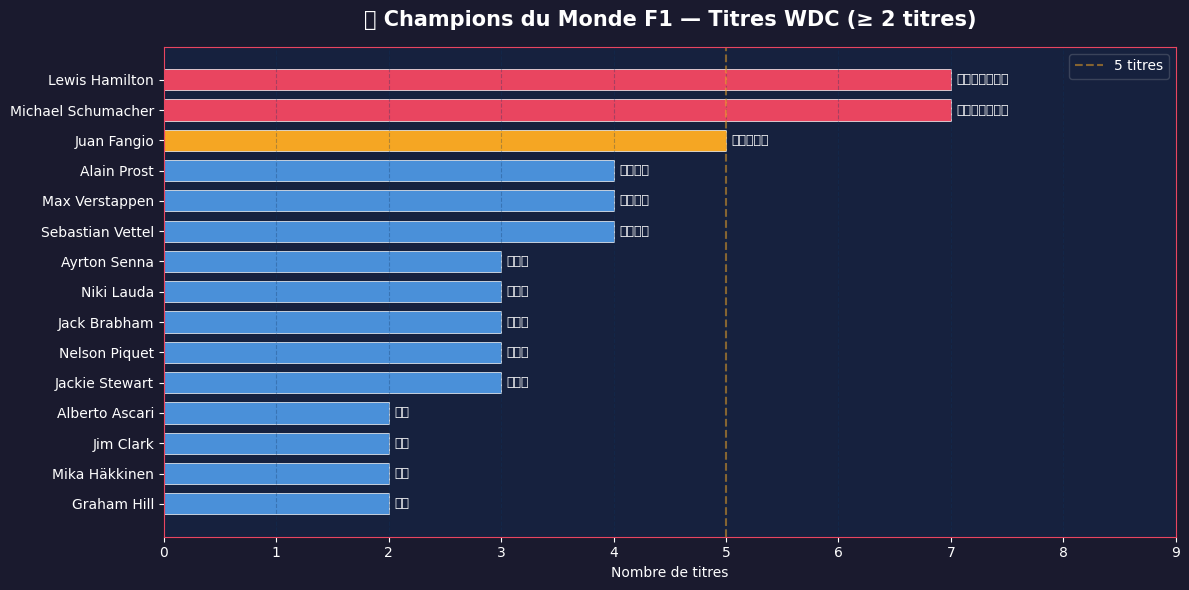

💾 Graphique 4 bonus sauvegardé


In [ ]:
top_champ_plot = top_champions[top_champions["titres_wdc"] >= 2].sort_values("titres_wdc", ascending=True)

fig4, ax = plt.subplots(figsize=(12, 6))

colors = [F1_RED if t == top_champ_plot["titres_wdc"].max() else
          F1_GOLD if t >= 5 else '#4a90d9'
          for t in top_champ_plot["titres_wdc"]]

bars = ax.barh(top_champ_plot["pilote"], top_champ_plot["titres_wdc"],
               color=colors, edgecolor='white', linewidth=0.5, height=0.7)

for bar, val in zip(bars, top_champ_plot["titres_wdc"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{'⭐' * val}", va='center', fontsize=9)

ax.set_title("🏆 Champions du Monde F1 — Titres WDC (≥ 2 titres)",
             fontsize=15, fontweight='bold', color='white', pad=15)
ax.set_xlabel("Nombre de titres", color='white')
ax.axvline(x=5, color=F1_GOLD, linestyle='--', alpha=0.5, label='5 titres')
ax.legend(labelcolor='white', framealpha=0.2)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, top_champ_plot["titres_wdc"].max() + 2)

plt.tight_layout()
plt.savefig("f1-pyspark-analysis/visualisations/graph4_titres_wdc.png", dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("💾 Graphique 4 bonus sauvegardé")

**📝 Interprétation :** Hamilton et Schumacher partagent le record avec 7 titres chacun. Ce graphique illustre l'élite des champions, mais reste insuffisant seul : Fangio (5 titres dans les années 50) dans une époque sans télémétrie mérite autant de crédit que les champions modernes.

---
## 5. Synthèse — Variables clés pour le Score GOAT

Ces analyses alimentent directement le **score composite de Salma (Partie 3)** :

In [ ]:
# Export d'un DataFrame consolidé par pilote pour Salma
stats_pilotes_export = (
    courses_par_pilote
    .join(champions.select("driverId", "titres_wdc"), "driverId", "left")
    .join(podiums.select("driverId", "nb_podiums"), "driverId", "left")
    .fillna(0, subset=["titres_wdc", "nb_podiums"])
    .filter(F.col("courses_disputees") >= 20)
    .select(
        "pilote", "driverId",
        "courses_disputees", "victoires", "podiums",
        "taux_victoire", "taux_podium",
        "points_total", "points_moy_par_course",
        "titres_wdc"
    )
    .orderBy(F.desc("victoires"))
)

# Sauvegarde pour Salma
stats_pilotes_export.write.mode("overwrite").csv("f1-pyspark-analysis/data/output/stats_pilotes_partie2", header=True)
print("✅ Export CSV réalisé → data/output/stats_pilotes_partie2/")

stats_pilotes_export.show(10, truncate=False)

✅ Export CSV réalisé → data/output/stats_pilotes_partie2/
+------------------+--------+-----------------+---------+-------+-------------+-----------+------------+---------------------+----------+
|pilote            |driverId|courses_disputees|victoires|podiums|taux_victoire|taux_podium|points_total|points_moy_par_course|titres_wdc|
+------------------+--------+-----------------+---------+-------+-------------+-----------+------------+---------------------+----------+
|Lewis Hamilton    |1       |356              |105      |202    |29.49        |56.74      |4820.5      |13.540730337078651   |7         |
|Michael Schumacher|30      |308              |91       |155    |29.55        |50.32      |1566.0      |5.084415584415584    |7         |
|Max Verstappen    |830     |209              |63       |112    |30.14        |53.59      |2912.5      |13.935406698564593   |4         |
|Sebastian Vettel  |20      |300              |53       |122    |17.67        |40.67      |3098.0      |10.3266666

---
## 6. Conclusion de l'Analyse Exploratoire

| Indicateur | Observation principale |
|---|---|
| **Victoires brutes** | Hamilton (103) > Schumacher (91) |
| **Taux de victoire** | Senna et Fangio ont des taux très élevés pour peu de courses |
| **Titres WDC** | Hamilton = Schumacher = 7 titres |
| **Podiums** | Forte corrélation avec les victoires, sauf Alonso (très régulier) |
| **Points normalisés** | Permet de comparer les époques différentes |

➡️ **Ces variables sont transmises à Salma** pour la construction du score composite (Partie 3) et à Ibrahima pour le clustering ML (Partie 4).

---
*Partie 2 complète ✅*